# Prédiction personnalisée client — 14 jours d'entrée → 2 jours prédits

**Objectif** : prédire la courbe de consommation future d'un client.

À partir de **14 jours passés** du client, on prédit **2 jours futurs** du même client.

Ce notebook compare quatre approches :

| # | Modèle | Description |
|---|--------|-------------|
| 1 | **Baseline récente** | Recopier les 2 derniers jours observés |
| 2 | **Baseline hebdomadaire** | Recopier les mêmes créneaux de la semaine précédente |
| 3 | **Ridge résiduel** | Apprend une correction de la meilleure baseline |
| 4 | **CNN 1D résiduel** | Réseau convolutif léger qui corrige aussi la baseline |

La métrique principale retenue est le **WMAPE** (Weighted MAPE), robuste aux consommations nulles.

> **Note** : le modèle reste volontairement léger pour éviter un temps d'exécution trop long.

## 0. Imports et configuration

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

try:
    import holidays
except ImportError:
    class _EmptyFranceHolidays:
        def __contains__(self, date):
            return False

    class holidays:
        @staticmethod
        def France(*args, **kwargs):
            print("Package 'holidays' non installé : is_holiday sera toujours 0.")
            return _EmptyFranceHolidays()

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import Dataset, DataLoader
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False

try:
    import lightgbm as lgb
    LGBM_AVAILABLE = True
except ImportError:
    LGBM_AVAILABLE = False

print(f"PyTorch      : {TORCH_AVAILABLE}")
print(f"LightGBM     : {LGBM_AVAILABLE}")
if TORCH_AVAILABLE:
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device       : {DEVICE}")
else:
    DEVICE = None

PyTorch      : True
LightGBM     : True
Device       : cpu


In [ ]:
#  Chemins 
BASE_DIR    = Path.cwd().parent
FILE_PATH   = "/content/RES2-6-9.csv"
LABELS_PATH = "/content/RES2-6-9-labels.csv"

# Dossier de sortie des figures 
FIG_DIR = BASE_DIR / "outputs" / "figures" / "prediction"
FIG_DIR.mkdir(parents=True, exist_ok=True)


INPUT_LEN = 672   # 14 jours × 48 demi-heures
HORIZON   = 96    # 2 jours × 48 demi-heures
STRIDE    = 48    # un point de départ par jour et par client

MIN_HISTORY_FOR_FEATURES = INPUT_LEN

# coupage temporel 
N_VAL_DAYS  = 30
N_TEST_DAYS = 30
GAP_DAYS    = HORIZON // 48  # 2 jours de gap anti-fuite

# e 
RIDGE_ALPHAS     = [1.0, 10.0, 100.0, 300.0]
SELECTION_METRIC = "WMAPE"
ACTIVE_DAY_KWH   = 1.0

# CNN 
RUN_CNN               = True
CNN_EPOCHS            = 8
CNN_BATCH_SIZE        = 512
CNN_LR                = 1e-3
CNN_WEIGHT_DECAY      = 1e-4
MAX_TRAIN_SAMPLES_CNN = 60_000
MAX_VAL_SAMPLES_CNN   = 20_000
RANDOM_STATE          = 42

# LightGBM 
LGBM_PARAMS = {
    "objective"        : "regression_l1",
    "n_estimators"     : 500,
    "learning_rate"    : 0.05,
    "num_leaves"       : 63,
    "min_child_samples": 20,
    "subsample"        : 0.8,
    "colsample_bytree" : 0.8,
    "reg_alpha"        : 0.1,
    "reg_lambda"       : 1.0,
    "random_state"     : 42,
    "n_jobs"           : -1,
    "verbose"          : -1,
}

# Mettre une valeur (ex: 50) pour accélérer les tests ; None = tous les clients
MAX_CLIENTS_PER_SEGMENT = None

np.random.seed(RANDOM_STATE)
if TORCH_AVAILABLE:
    torch.manual_seed(RANDOM_STATE)

print(f"Entrée : {INPUT_LEN} demi-heures = {INPUT_LEN // 48} jours")
print(f"Sortie : {HORIZON} demi-heures  = {HORIZON // 48} jours")
print(f"Validation : {N_VAL_DAYS} j | Test : {N_TEST_DAYS} j | Gap : {GAP_DAYS} j")
print(f"Figures sauvegardées dans : {FIG_DIR}")

Entrée : 672 demi-heures = 14 jours
Sortie : 96 demi-heures  = 2 jours
Validation : 30 j | Test : 30 j | Gap : 2 j
Figures sauvegardées dans : /outputs/figures/prediction


## 1. Chargement des données

Deux fichiers sont utilisés :

| Fichier | Colonnes principales |
|---------|----------------------|
| `RES2-6-9.csv` | `pdl_id`, `horodate`, `puissance_w` |
| `RES2-6-9-labels.csv` | `pdl_id`, `label_rs_rp` (0=RS, 1=RP), `cluster_ref` |

La puissance en W est convertie en **kWh sur 30 min** : `kwh = puissance_w × 0.5 / 1000`.

In [ ]:
# ls RS / RP 
ref = pd.read_csv(LABELS_PATH)
ref.columns = ["pdl_id", "label_rs_rp", "cluster_ref"]
# Convention fichier : 0 = RS  /  1 = RP
ref["segment"] = np.where(ref["label_rs_rp"] == 0, "RS", "RP")

print("Répartition des clients :")
print(ref["segment"].value_counts())

# ées brutes 
raw = pd.read_csv(FILE_PATH)
raw.columns = ["pdl_id", "horodate", "puissance_w"]
raw["horodate"]   = pd.to_datetime(raw["horodate"], utc=True, errors="coerce")
raw["puissance_w"] = pd.to_numeric(raw["puissance_w"], errors="coerce")
raw = raw.dropna(subset=["pdl_id", "horodate", "puissance_w"])

# Jointure labels
raw = raw.merge(ref[["pdl_id", "label_rs_rp", "segment"]], on="pdl_id", how="inner")

# Conversion W → kWh/30min
raw["kwh"] = raw["puissance_w"] * 0.5 / 1000
raw = raw.sort_values(["pdl_id", "horodate"]).reset_index(drop=True)

# Réduction optionnelle du nombre de clients pour les tests rapides
if MAX_CLIENTS_PER_SEGMENT is not None:
    keep_pdls = []
    for seg in ["RS", "RP"]:
        pdls_seg = raw.loc[raw["segment"] == seg, "pdl_id"].drop_duplicates()
        keep_pdls.extend(pdls_seg.head(MAX_CLIENTS_PER_SEGMENT).tolist())
    raw = raw[raw["pdl_id"].isin(keep_pdls)].copy()

print(f"\nLignes   : {len(raw):,}")
print(f"Période  : {raw['horodate'].min()} → {raw['horodate'].max()}")
print(f"Clients  : {raw['pdl_id'].nunique()}")
print("Répartition des lignes :")
print(raw["segment"].value_counts())
raw.head(3)

Répartition des clients :
segment
RS    428
RP     72
Name: count, dtype: int64

Lignes   : 8,736,000
Période  : 2023-10-31 23:00:00+00:00 → 2024-10-29 22:30:00+00:00
Clients  : 500
Répartition des lignes :
segment
RS    7478016
RP    1257984
Name: count, dtype: int64


,pdl_id,horodate,puissance_w,label_rs_rp,segment,kwh
0,1704875583,2023-10-31 23:00:00+00:00,308.8,0,RS,0.1544
1,1704875583,2023-10-31 23:30:00+00:00,330.4,0,RS,0.1652
2,1704875583,2023-11-01 00:00:00+00:00,299.0,0,RS,0.1495


## 2. Métriques et features

### 2.1 Métriques

| Métrique | Formule | Remarque |
|----------|---------|----------|
| **MAE** | `mean(|y - ŷ|)` | Interprétable (kWh) |
| **RMSE** | `sqrt(mean((y-ŷ)²))` | Pénalise les gros écarts |
| **WMAPE** | `sum(|y-ŷ|) / sum(|y|) × 100` | Robuste aux zéros ← **métrique principale** |
| **sMAPE** | symétrique MAPE | Moins sensible aux outliers |
| **MAPE filtré** | MAPE sur `y > 0.10` kWh | Élimine les créneaux d'inactivité |

### 2.2 Features

Pour chaque fenêtre de prédiction, on construit :

```
X_tab = [X_seq (672 valeurs) | X_extra (features tabulaires)]
```

**X_extra** contient des variables **calendaires**, des **lags individuels**, des **statistiques mobiles** (1, 2, 7, 14 jours) et des **indicateurs d'activité** passée.

In [ ]:
# iques 

def smape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denom > 1e-8
    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denom[mask]) * 100 if mask.sum() else np.nan

def wmape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    denom = np.sum(np.abs(y_true))
    return np.sum(np.abs(y_true - y_pred)) / denom * 100 if denom > 1e-8 else np.nan

def mape_raw(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    denom = np.where(np.abs(y_true) <= 1e-8, np.nan, y_true)
    return np.nanmean(np.abs((y_true - y_pred) / denom)) * 100

def filtered_mape(y_true, y_pred, threshold=0.10):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    mask = y_true > threshold
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if mask.sum() else np.nan

def regression_metrics(y_true, y_pred, prefix=""):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return {
        prefix + "MAE"             : mean_absolute_error(y_true, y_pred),
        prefix + "RMSE"            : np.sqrt(mean_squared_error(y_true, y_pred)),
        prefix + "WMAPE"           : wmape(y_true, y_pred),
        prefix + "sMAPE"           : smape(y_true, y_pred),
        prefix + "MAPE_brut"       : mape_raw(y_true, y_pred),
        prefix + "MAPE_filtre_010" : filtered_mape(y_true, y_pred, 0.10),
    }

def print_metrics(title, metrics):
    print("=" * 70)
    print(title)
    print("=" * 70)
    for k, v in metrics.items():
        if isinstance(v, (float, np.floating)):
            suffix = " %" if any(m in k for m in ["MAPE", "WMAPE", "sMAPE"]) else ""
            fmt    = f"{v:8.2f}{suffix}" if suffix else f"{v:8.4f}"
            print(f"{k:22s}: {fmt}")
        else:
            print(f"{k:22s}: {v}")

In [ ]:
#  Features extra 

annees = sorted(raw["horodate"].dt.year.unique())
fr_holidays = holidays.France(years=annees)

def is_school_holiday_proxy(dt):
    """Proxy simple : mois de vacances fréquentes en France."""
    return int(dt.month in [7, 8, 12])

def season_from_month(m):
    return {12:0, 1:0, 2:0, 3:1, 4:1, 5:1, 6:2, 7:2, 8:2}.get(m, 3)

def longest_run_bool(values):
    best = cur = 0
    for v in values:
        cur = cur + 1 if v else 0
        best = max(best, cur)
    return best

def build_extra_features(past_seq, anchor_time, segment):
    """
    Construit le vecteur de features extra à partir :
      - past_seq   : 14 jours passés (672 valeurs kWh/30min)
      - anchor_time : dernier horodatage observé
      - segment    : 'RS' ou 'RP'
    """
    past_seq = np.asarray(past_seq, dtype=np.float32)
    forecast_start = anchor_time + pd.Timedelta(minutes=30)
    dow    = forecast_start.weekday()
    month  = forecast_start.month
    season = season_from_month(month)

    last_1d  = past_seq[-48:]
    last_2d  = past_seq[-96:]
    last_7d  = past_seq[-336:]
    last_14d = past_seq[-672:]

    active_30     = past_seq > 0.02
    daily_e14     = last_14d.reshape(-1, 48).sum(axis=1)
    active_days14 = daily_e14 > ACTIVE_DAY_KWH
    daily_e7      = last_7d.reshape(-1, 48).sum(axis=1)
    active_days7  = daily_e7 > ACTIVE_DAY_KWH

    past_day_dates  = [forecast_start.normalize() - pd.Timedelta(days=d) for d in range(14, 0, -1)]
    is_weekend_past = np.array([d.weekday() >= 5 for d in past_day_dates])

    eps = 1e-6
    weekday_energy = daily_e14[~is_weekend_past].sum() if (~is_weekend_past).any() else 0.0
    weekend_energy = daily_e14[is_weekend_past].sum()  if  is_weekend_past.any()  else 0.0

    feats = [
        # Calendrier
        np.sin(2*np.pi*dow/7), np.cos(2*np.pi*dow/7),
        float(dow >= 5),
        np.sin(2*np.pi*month/12), np.cos(2*np.pi*month/12),
        float(forecast_start.date() in fr_holidays),
        float(is_school_holiday_proxy(forecast_start)),
    ] + [float(season == s) for s in range(4)] + [float(segment=="RS"), float(segment=="RP")]

    # Lags individuels
    feats += [past_seq[-1], past_seq[-48], past_seq[-96], past_seq[-336], past_seq[-672]]

    # Stats mobiles : 1, 2, 7, 14 jours
    for arr in [last_1d, last_2d, last_7d, last_14d]:
        feats += [arr.mean(), arr.std(), arr.min(), arr.max(), arr.sum()]

    # Activité passée
    feats += [
        active_30[-48:].mean(), active_30[-96:].mean(),
        active_30[-336:].mean(), active_30[-672:].mean(),
        active_days7.mean(),  active_days14.mean(),
        active_days7.sum(),   active_days14.sum(),
        longest_run_bool(active_days14),
        daily_e7.mean(),  daily_e7.std(),
        daily_e14.mean(), daily_e14.std(),
        weekend_energy, weekday_energy,
        weekend_energy / (weekday_energy + eps),
        # Ratios de niveau
        last_7d.mean()  / (last_14d.mean() + eps),
        last_2d.mean()  / (last_7d.mean()  + eps),
        last_1d.mean()  / (last_7d.mean()  + eps),
        last_7d.mean()  - last_14d.mean(),
        last_2d.mean()  - last_7d.mean(),
        last_1d.mean()  - last_7d.mean(),
    ]
    return np.asarray(feats, dtype=np.float32)


EXTRA_FEATURE_NAMES = [
    "dow_sin", "dow_cos", "is_weekend_start", "month_sin", "month_cos",
    "is_holiday_start", "is_school_holiday_proxy",
    "season_winter", "season_spring", "season_summer", "season_autumn",
    "is_RS", "is_RP",
    "lag_1", "lag_48", "lag_96", "lag_336", "lag_672",
]
for w in ["1d", "2d", "7d", "14d"]:
    EXTRA_FEATURE_NAMES += [f"mean_{w}", f"std_{w}", f"min_{w}", f"max_{w}", f"sum_{w}"]
EXTRA_FEATURE_NAMES += [
    "active_rate_1d", "active_rate_2d", "active_rate_7d", "active_rate_14d",
    "active_days_rate_7d", "active_days_rate_14d",
    "active_days_count_7d", "active_days_count_14d",
    "longest_active_run_14d",
    "daily_energy_7d_mean", "daily_energy_7d_std",
    "daily_energy_14d_mean", "daily_energy_14d_std",
    "weekend_energy_14d", "weekday_energy_14d",
    "weekend_over_weekday",
    "ratio_mean_7d_14d", "ratio_mean_2d_7d", "ratio_mean_1d_7d",
    "diff_mean_7d_14d", "diff_mean_2d_7d", "diff_mean_1d_7d",
]
print(f"Nombre de features extra : {len(EXTRA_FEATURE_NAMES)}")

Nombre de features extra : 60


## 3. Construction des fenêtres glissantes

Pour chaque client, on construit des exemples de la forme :

```
X_seq   = 14 jours passés     → 672 valeurs kWh/30min
X_extra = features tabulaires → vecteur de features
Y       = 2 jours futurs      →  96 valeurs kWh/30min
```

Le stride de `STRIDE = 48` génère **un exemple par jour** par client.

Les baselines suivantes sont précalculées à la construction :
- **baseline récente** : les 2 derniers jours observés (`past_seq[-96:]`)
- **baseline hebdomadaire** : les 2 mêmes jours de la semaine précédente

In [7]:
def build_windows_for_client(g):
    g       = g.sort_values("horodate")
    values  = g["kwh"].to_numpy(dtype=np.float32)
    times   = g["horodate"].to_numpy()
    pdl     = g["pdl_id"].iloc[0]
    segment = g["segment"].iloc[0]

    n, rows = len(g), []
    max_start = n - INPUT_LEN - HORIZON
    if max_start < 0:
        return rows

    for start in range(0, max_start + 1, STRIDE):
        input_end  = start + INPUT_LEN
        target_end = input_end + HORIZON

        past_seq   = values[start:input_end]
        future_seq = values[input_end:target_end]
        anchor_time    = pd.Timestamp(times[input_end - 1])
        forecast_start = anchor_time + pd.Timedelta(minutes=30)

        # Baselines précalculées
        b_recent = past_seq[-HORIZON:]                          # 2 derniers jours
        b_weekly = past_seq[INPUT_LEN-336:INPUT_LEN-336+HORIZON]  # même créneau -1 semaine

        x_extra = build_extra_features(past_seq, anchor_time, segment)

        rows.append({
            "pdl_id"        : pdl,
            "segment"       : segment,
            "forecast_start": forecast_start,
            "x_seq"         : past_seq,
            "x_extra"       : x_extra,
            "y"             : future_seq,
            "b_recent"      : b_recent,
            "b_weekly"      : b_weekly,
        })
    return rows


print("Construction des fenêtres...")
all_rows = []
for pdl_id, grp in raw.groupby("pdl_id"):
    all_rows.extend(build_windows_for_client(grp))

windows = pd.DataFrame(all_rows)
forecast_starts = windows["forecast_start"]

# Matrices numpy
X_seq   = np.vstack(windows["x_seq"].values).astype(np.float32)
X_extra = np.vstack(windows["x_extra"].values).astype(np.float32)
Y       = np.vstack(windows["y"].values).astype(np.float32)
B_recent = np.vstack(windows["b_recent"].values).astype(np.float32)
B_weekly = np.vstack(windows["b_weekly"].values).astype(np.float32)

print(f"Fenêtres construites : {len(windows):,}")
print(f"X_seq   : {X_seq.shape}")
print(f"X_extra : {X_extra.shape}")
print(f"Y       : {Y.shape}")

Construction des fenêtres...
Fenêtres construites : 174,500
X_seq   : (174500, 672)
X_extra : (174500, 60)
Y       : (174500, 96)


## 4. Découpage train / validation / test

Le découpage est **chronologique** (pas de mélange aléatoire) pour simuler les conditions réelles.

```
Timeline :  IN AP | VAL (30j) | GAP | TEST (30j)
```

Un **gap de 2 jours** est inséré entre chaque partie pour éviter toute fuite de données (les 14 jours d'entrée pourraient chevaucher la cible sinon).

In [9]:
all_dates = forecast_starts.values
t_max = pd.Timestamp(all_dates.max()).tz_localize('UTC') # Ensure t_max is UTC-aware

test_start = t_max - pd.Timedelta(days=N_TEST_DAYS)
val_start  = test_start - pd.Timedelta(days=N_VAL_DAYS + GAP_DAYS)
train_end  = val_start - pd.Timedelta(days=GAP_DAYS)

idx_train = np.where(forecast_starts < train_end)[0]
idx_val   = np.where((forecast_starts >= val_start)  & (forecast_starts < test_start))[0]
idx_test  = np.where( forecast_starts >= test_start)[0]

print(f"Train  : {len(idx_train):>6,} exemples  (→ {train_end.date()})")
print(f"Val    : {len(idx_val):>6,} exemples  ({val_start.date()} → {test_start.date()})")
print(f"Test   : {len(idx_test):>6,} exemples  ({test_start.date()} →)")

Train  : 142,000 exemples  (→ 2024-08-24)
Val    : 16,000 exemples  (2024-08-26 → 2024-09-27)
Test   : 15,500 exemples  (2024-09-27 →)


## 5. Baselines

Les deux baselines servent de **référence** et, pour les modèles résiduels, de **point de départ**.

In [10]:
def evaluate_prediction_by_segment(Y_all, Y_pred_all, idx, model_name):
    """Calcule les métriques par segment (RS, RP, ALL)."""
    segs = windows.iloc[idx]["segment"].values
    rows = []
    for seg in ["RS", "RP", "ALL"]:
        mask = np.ones(len(idx), dtype=bool) if seg == "ALL" else (segs == seg)
        idx_seg = idx[mask]
        if len(idx_seg) == 0:
            continue
        m = regression_metrics(Y_all[idx_seg].flatten(), Y_pred_all[idx_seg].flatten())
        m["modele"]     = model_name
        m["segment"]    = seg
        m["n_examples"] = len(idx_seg)
        rows.append(m)
    return pd.DataFrame(rows)


# Évaluation baseline
baseline_val = pd.concat([
    evaluate_prediction_by_segment(Y, B_recent, idx_val, "baseline_recent"),
    evaluate_prediction_by_segment(Y, B_weekly, idx_val, "baseline_weekly"),
], ignore_index=True)

print("Résultats validation — Baselines")
display(baseline_val[["modele", "segment", "n_examples", "MAE", "RMSE", "WMAPE", "sMAPE"]])

# Choix de la meilleure baseline par segment
baseline_choice = {}
for seg in ["RS", "RP", "ALL"]:
    df_seg = baseline_val[baseline_val["segment"] == seg].sort_values(SELECTION_METRIC)
    if len(df_seg):
        baseline_choice[seg] = df_seg.iloc[0]["modele"]
print("\nMeilleure baseline par segment :")
for seg, choice in baseline_choice.items():
    print(f"  {seg} : {choice}")

BASELINE_MODEL = baseline_choice.get("ALL", "baseline_weekly")
B_base = B_recent if BASELINE_MODEL == "baseline_recent" else B_weekly
print(f"\nBaseline pour les modèles résiduels : {BASELINE_MODEL}")

Résultats validation — Baselines


,modele,segment,n_examples,MAE,RMSE,WMAPE,sMAPE
0,baseline_recent,RS,13696,0.141753,0.286976,65.972557,61.305553
1,baseline_recent,RP,2304,0.121444,0.266296,59.283333,59.727161
2,baseline_recent,ALL,16000,0.138828,0.284091,65.047958,61.094517
3,baseline_weekly,RS,13696,0.160408,0.313197,74.654854,68.291893
4,baseline_weekly,RP,2304,0.137557,0.290107,67.148605,68.568604
5,baseline_weekly,ALL,16000,0.157117,0.309978,73.617348,68.329445



Meilleure baseline par segment :
  RS : baseline_recent
  RP : baseline_recent
  ALL : baseline_recent

Baseline pour les modèles résiduels : baseline_recent


## 6. Ridge résiduel

Le modèle Ridge **ne prédit pas directement** la courbe future, mais apprend la **correction** à apporter à la baseline :

$$\hat{Y} = Y_{\text{baseline}} + \hat{R}$$

avec $\hat{R}$ le résidu prédit par Ridge. Cela stabilise l'apprentissage quand la baseline est déjà bonne.

In [11]:
X_tab      = np.hstack([X_seq, X_extra]).astype(np.float32)
Y_residual = (Y - B_base).astype(np.float32)

print(f"X_tab      : {X_tab.shape}")
print(f"Y_residual : {Y_residual.shape}")

X_tab      : (174500, 732)
Y_residual : (174500, 96)


In [12]:
ridge_results = []
ridge_models  = {}

for alpha in RIDGE_ALPHAS:
    print(f"Entraînement Ridge alpha={alpha}")
    model = make_pipeline(StandardScaler(with_mean=True), Ridge(alpha=alpha))
    model.fit(X_tab[idx_train], Y_residual[idx_train])
    ridge_models[alpha] = model

    pred_res_val = model.predict(X_tab[idx_val]).astype(np.float32)
    pred_val     = np.clip(B_base[idx_val] + pred_res_val, 0, None)
    m            = regression_metrics(Y[idx_val], pred_val)
    m["alpha"]   = alpha
    ridge_results.append(m)

ridge_results = pd.DataFrame(ridge_results).sort_values(SELECTION_METRIC).reset_index(drop=True)
print("\nRésultats validation — Ridge résiduel :")
display(ridge_results)

best_alpha   = float(ridge_results.iloc[0]["alpha"])
ridge_model  = ridge_models[best_alpha]
print(f"\nMeilleur alpha Ridge : {best_alpha}")

Entraînement Ridge alpha=1.0
Entraînement Ridge alpha=10.0
Entraînement Ridge alpha=100.0
Entraînement Ridge alpha=300.0

Résultats validation — Ridge résiduel :


,MAE,RMSE,WMAPE,sMAPE,MAPE_brut,MAPE_filtre_010,alpha
0,0.130342,0.218890,61.071785,69.109802,1086.089600,53.327728,1.0
1,0.130343,0.218890,61.072086,69.109520,1086.137451,53.327805,10.0
2,0.130350,0.218889,61.075264,69.109413,1086.615601,53.328537,100.0
3,0.130367,0.218890,61.083370,69.110405,1087.664185,53.331421,300.0



Meilleur alpha Ridge : 1.0


In [15]:
pred_res_val   = ridge_model.predict(X_tab[idx_val]).astype(np.float32)
# pred_ridge_val contains only the predictions for the validation set
pred_ridge_val_subset = np.clip(B_base[idx_val] + pred_res_val, 0, None)

# Create a full-sized prediction array for evaluation purposes
full_pred_ridge_val = np.full(Y.shape, np.nan, dtype=np.float32)
full_pred_ridge_val[idx_val] = pred_ridge_val_subset

ridge_val_table = evaluate_prediction_by_segment(Y, full_pred_ridge_val, idx_val, "ridge_residual")
print("Résultats validation — Ridge résiduel")
display(ridge_val_table[["modele", "segment", "n_examples", "MAE", "RMSE", "WMAPE", "MAPE_filtre_010", "sMAPE"]])

Résultats validation — Ridge résiduel


,modele,segment,n_examples,MAE,RMSE,WMAPE,MAPE_filtre_010,sMAPE
0,ridge_residual,RS,13696,0.133067,0.221119,61.929955,53.664131,68.149742
1,ridge_residual,RP,2304,0.114147,0.205146,55.721218,51.070576,74.970665
2,ridge_residual,ALL,16000,0.130342,0.218891,61.071785,53.327728,69.109802


## 7. LightGBM résiduel

LightGBM est entraîné sur `X_extra` uniquement (sans la séquence brute : trop de features pour les arbres).  
Il utilise `MultiOutputRegressor` pour prédire les 96 pas de temps simultanément.

> **`objective='regression_l1'`** (MAE) est plus robuste aux consommations nulles (RS hors vacances).

In [25]:
lgbm_model   = None
pred_lgbm_val = None # This will now be primarily a placeholder or renamed for consistency
lgbm_val_table = pd.DataFrame()

if LGBM_AVAILABLE:
    from sklearn.multioutput import MultiOutputRegressor
    print("Entraînement LightGBM résiduel...")

    lgbm_model = MultiOutputRegressor(lgb.LGBMRegressor(**LGBM_PARAMS), n_jobs=1)
    lgbm_model.fit(X_extra[idx_train], Y_residual[idx_train])

    pred_res_lgbm_val = lgbm_model.predict(X_extra[idx_val]).astype(np.float32)
    # The current pred_lgbm_val is a subset for validation indices
    pred_lgbm_val_subset = np.clip(B_base[idx_val] + pred_res_lgbm_val, 0, None)

    # Create a full-sized prediction array for evaluation purposes
    full_pred_lgbm_val = np.full(Y.shape, np.nan, dtype=np.float32)
    full_pred_lgbm_val[idx_val] = pred_lgbm_val_subset

    lgbm_val_table = evaluate_prediction_by_segment(Y, full_pred_lgbm_val, idx_val, "lgbm_residual")
    print("Résultats validation — LightGBM résiduel")
    display(lgbm_val_table[["modele", "segment", "n_examples", "MAE", "RMSE", "WMAPE", "sMAPE"]])
else:
    print("LightGBM non disponible. pip install lightgbm")

Entraînement LightGBM résiduel...
Résultats validation — LightGBM résiduel


,modele,segment,n_examples,MAE,RMSE,WMAPE,sMAPE
0,lgbm_residual,RS,13696,0.137938,0.280502,64.197357,61.433784
1,lgbm_residual,RP,2304,0.117869,0.260139,57.538094,64.117271
2,lgbm_residual,ALL,16000,0.135048,0.277662,63.276924,61.805225


## 8. CNN 1D résiduel léger

Le CNN reçoit la séquence des 14 jours passés **et** les features extra individuelles.  
Il prédit le même résidu que Ridge :

$$\hat{Y} = \text{baseline} + \text{correction}_{\text{CNN}}$$

Le modèle est volontairement léger (8 epochs, sous-échantillonnage du train) pour limiter le temps de calcul.

In [17]:
if not TORCH_AVAILABLE:
    print("PyTorch non disponible : partie CNN ignorée.")
    RUN_CNN = False


class SequenceDataset(Dataset):
    def __init__(self, idx, x_seq, x_extra, y_res):
        self.idx, self.x_seq, self.x_extra, self.y_res = np.asarray(idx), x_seq, x_extra, y_res

    def __len__(self):
        return len(self.idx)

    def __getitem__(self, i):
        j = self.idx[i]
        return torch.from_numpy(self.x_seq[j]), torch.from_numpy(self.x_extra[j]), torch.from_numpy(self.y_res[j])


class ResidualCNN1D(nn.Module):
    def __init__(self, n_extra, output_len):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3), nn.ReLU(), nn.BatchNorm1d(32), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=7, padding=3), nn.ReLU(), nn.BatchNorm1d(64), nn.MaxPool1d(2),
            nn.Conv1d(64, 64, kernel_size=5, padding=2), nn.ReLU(), nn.AdaptiveAvgPool1d(32), nn.Flatten(),
        )
        self.head = nn.Sequential(
            nn.Linear(64 * 32 + n_extra, 256), nn.ReLU(), nn.Dropout(0.15), nn.Linear(256, output_len),
        )

    def forward(self, x_seq, x_extra):
        return self.head(torch.cat([self.cnn(x_seq.unsqueeze(1)), x_extra], dim=1))


print("Classes CNN prêtes")

Classes CNN prêtes


In [18]:
def sample_indices(idx, max_samples, seed=RANDOM_STATE):
    idx = np.asarray(idx)
    if max_samples is None or len(idx) <= max_samples:
        return idx
    return np.random.default_rng(seed).choice(idx, size=max_samples, replace=False)


cnn_model   = None
cnn_history = []
seq_scale = extra_mean = extra_std = None  # initialisés dans le bloc CNN

if RUN_CNN:
    idx_train_cnn = sample_indices(idx_train, MAX_TRAIN_SAMPLES_CNN)
    idx_val_cnn   = sample_indices(idx_val,   MAX_VAL_SAMPLES_CNN, seed=RANDOM_STATE + 1)

    # Normalisation des features extra (uniquement pour le CNN)
    extra_mean  = X_extra[idx_train_cnn].mean(axis=0, keepdims=True)
    extra_std   = X_extra[idx_train_cnn].std(axis=0,  keepdims=True) + 1e-6
    X_extra_cnn = ((X_extra - extra_mean) / extra_std).astype(np.float32)

    # Normalisation légère de la séquence (facteur global)
    seq_scale = np.percentile(X_seq[idx_train_cnn], 95)
    if not np.isfinite(seq_scale) or seq_scale <= 1e-6:
        seq_scale = 1.0
    X_seq_cnn       = (X_seq       / seq_scale).astype(np.float32)
    Y_residual_cnn  = (Y_residual  / seq_scale).astype(np.float32)

    train_loader = DataLoader(
        SequenceDataset(idx_train_cnn, X_seq_cnn, X_extra_cnn, Y_residual_cnn),
        batch_size=CNN_BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(
        SequenceDataset(idx_val_cnn, X_seq_cnn, X_extra_cnn, Y_residual_cnn),
        batch_size=CNN_BATCH_SIZE, shuffle=False, num_workers=0)

    cnn_model = ResidualCNN1D(n_extra=X_extra.shape[1], output_len=HORIZON).to(DEVICE)
    optimizer = torch.optim.AdamW(cnn_model.parameters(), lr=CNN_LR, weight_decay=CNN_WEIGHT_DECAY)
    loss_fn   = nn.SmoothL1Loss()

    best_val_loss = np.inf
    best_state    = None
    patience_count = 0
    PATIENCE = 2

    print(f"Train CNN : {len(idx_train_cnn):,} ex | Val CNN : {len(idx_val_cnn):,} ex")
    for epoch in range(1, CNN_EPOCHS + 1):
        cnn_model.train()
        train_losses = []
        for xb_seq, xb_extra, yb in train_loader:
            xb_seq, xb_extra, yb = xb_seq.to(DEVICE), xb_extra.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = loss_fn(cnn_model(xb_seq, xb_extra), yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        cnn_model.eval()
        val_losses = []
        with torch.no_grad():
            for xb_seq, xb_extra, yb in val_loader:
                xb_seq, xb_extra, yb = xb_seq.to(DEVICE), xb_extra.to(DEVICE), yb.to(DEVICE)
                val_losses.append(loss_fn(cnn_model(xb_seq, xb_extra), yb).item())

        tl, vl = float(np.mean(train_losses)), float(np.mean(val_losses))
        cnn_history.append({"epoch": epoch, "train_loss": tl, "val_loss": vl})
        print(f"Epoch {epoch:02d} | train={tl:.5f} | val={vl:.5f}")

        if vl < best_val_loss:
            best_val_loss  = vl
            best_state     = {k: v.detach().cpu().clone() for k, v in cnn_model.state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= PATIENCE:
                print("Early stopping.")
                break

    if best_state:
        cnn_model.load_state_dict(best_state)
    print("CNN entraîné.")
else:
    print("CNN non exécuté.")

Train CNN : 60,000 ex | Val CNN : 16,000 ex
Epoch 01 | train=0.03077 | val=0.01947
Epoch 02 | train=0.02859 | val=0.01897
Epoch 03 | train=0.02808 | val=0.01873
Epoch 04 | train=0.02776 | val=0.01866
Epoch 05 | train=0.02751 | val=0.01851
Epoch 06 | train=0.02729 | val=0.01851
Epoch 07 | train=0.02707 | val=0.01842
Epoch 08 | train=0.02687 | val=0.01819
CNN entraîné.


In [20]:
def predict_cnn_for_indices(idx, batch_size=1024):
    if cnn_model is None:
        return None
    preds = []
    cnn_model.eval()
    with torch.no_grad():
        for start in range(0, len(idx), batch_size):
            part       = idx[start:start + batch_size]
            xb_seq     = torch.from_numpy(X_seq_cnn[part]).to(DEVICE)
            xb_extra   = torch.from_numpy(X_extra_cnn[part]).to(DEVICE)
            pred_res   = cnn_model(xb_seq, xb_extra).cpu().numpy() * seq_scale
            preds.append(np.clip(B_base[part] + pred_res, 0, None).astype(np.float32))
    return np.vstack(preds)


pred_cnn_val   = None
cnn_val_table  = pd.DataFrame()

if RUN_CNN and cnn_model is not None:
    pred_cnn_val_subset = predict_cnn_for_indices(idx_val)

    # Create a full-sized prediction array for evaluation purposes
    full_pred_cnn_val = np.full(Y.shape, np.nan, dtype=np.float32)
    full_pred_cnn_val[idx_val] = pred_cnn_val_subset

    cnn_val_table = evaluate_prediction_by_segment(Y, full_pred_cnn_val, idx_val, "cnn_residual")
    print("Résultats validation — CNN")
    display(cnn_val_table[["modele", "segment", "n_examples", "MAE", "RMSE", "WMAPE", "MAPE_filtre_010", "sMAPE"]])

Résultats validation — CNN


,modele,segment,n_examples,MAE,RMSE,WMAPE,MAPE_filtre_010,sMAPE
0,cnn_residual,RS,13696,0.143971,0.269561,67.005112,61.833000,71.581993
1,cnn_residual,RP,2304,0.124397,0.251060,60.724586,59.153019,79.573318
2,cnn_residual,ALL,16000,0.141153,0.266976,66.137032,61.485374,72.732201


## 9. Évaluation finale sur le jeu de test

In [ ]:
pred_res_test    = ridge_model.predict(X_tab[idx_test]).astype(np.float32)
pred_ridge_test  = np.clip(B_base[idx_test] + pred_res_test, 0, None)

# Create a full-sized array for evaluate_prediction_by_segment for Ridge
full_pred_ridge_test = np.full(Y.shape, np.nan, dtype=np.float32)
full_pred_ridge_test[idx_test] = pred_ridge_test


# LightGBM residual predictions for the test set (this is the subset of predictions)
pred_lgbm_test = None # Initialize to None
full_pred_lgbm_test = np.full(Y.shape, np.nan, dtype=np.float32) # Initialize full array
if LGBM_AVAILABLE and lgbm_model is not None:
    pred_lgbm_test = np.clip(
        B_base[idx_test] + lgbm_model.predict(X_extra[idx_test]).astype(np.float32), 0, None)
    full_pred_lgbm_test[idx_test] = pred_lgbm_test # Populate full array with subset


# CNN residual predictions for the test set (this is the subset of predictions)
pred_cnn_test = None # Initialize to None
full_pred_cnn_test = np.full(Y.shape, np.nan, dtype=np.float32) # Initialize full array
if RUN_CNN and cnn_model is not None:
    pred_cnn_test = predict_cnn_for_indices(idx_test)
    full_pred_cnn_test[idx_test] = pred_cnn_test # Populate full array with subset


# ble de résultats 
all_test_tables = [
    # For baselines, B_recent and B_weekly are full arrays, so they can be passed directly.
    evaluate_prediction_by_segment(Y, B_recent,         idx_test, "baseline_recent"),
    evaluate_prediction_by_segment(Y, B_weekly,         idx_test, "baseline_weekly"),
    # For residual models, pass the full-sized prediction arrays for evaluation
    evaluate_prediction_by_segment(Y, full_pred_ridge_test,  idx_test, "ridge_residual"),
]
if pred_lgbm_test is not None: # Check if the subset variable was populated
    all_test_tables.append(evaluate_prediction_by_segment(Y, full_pred_lgbm_test, idx_test, "lgbm_residual"))
if pred_cnn_test is not None: # Check if the subset variable was populated
    all_test_tables.append(evaluate_prediction_by_segment(Y, full_pred_cnn_test, idx_test, "cnn_residual"))

test_results = pd.concat(all_test_tables, ignore_index=True)

print("—" * 70)
print("RÉSULTATS TEST FINAL")
print("—" * 70)
display(
    test_results[
        ["modele", "segment", "n_examples", "MAE", "RMSE", "WMAPE", "MAPE_filtre_010", "sMAPE"]
    ].sort_values(["segment", SELECTION_METRIC])
)


——————————————————————————————————————————————————————————————————————
RÉSULTATS TEST FINAL
——————————————————————————————————————————————————————————————————————


,modele,segment,n_examples,MAE,RMSE,WMAPE,MAPE_filtre_010,sMAPE
8,ridge_residual,ALL,15500,0.152490,0.241383,61.762524,57.687847,70.009216
11,lgbm_residual,ALL,15500,0.157979,0.303874,63.985737,63.362068,62.827759
2,baseline_recent,ALL,15500,0.163054,0.312781,66.041435,66.133728,62.805664
14,cnn_residual,ALL,15500,0.163926,0.291424,66.394577,64.804039,72.331161
5,baseline_weekly,ALL,15500,0.183413,0.340206,74.287430,74.001221,70.314384
7,ridge_residual,RP,2232,0.138492,0.231301,56.820084,57.405430,76.554146
10,lgbm_residual,RP,2232,0.142784,0.291333,58.580864,62.846588,62.234573
1,baseline_recent,RP,2232,0.147945,0.300322,60.698528,65.872108,58.751888
13,cnn_residual,RP,2232,0.149030,0.279989,61.143513,64.804802,77.758377
4,baseline_weekly,RP,2232,0.168249,0.326987,69.028824,74.956390,67.913757


In [ ]:
# hèse val / test 
validation_tables = [baseline_val, ridge_val_table]
if len(lgbm_val_table):  validation_tables.append(lgbm_val_table)
if len(cnn_val_table):   validation_tables.append(cnn_val_table)
validation_results = pd.concat(validation_tables, ignore_index=True)

best_by_val = {}
print("Meilleur modèle par segment (validation) :")
for seg in ["RS", "RP", "ALL"]:
    df_seg = validation_results[validation_results["segment"] == seg].sort_values(SELECTION_METRIC)
    if len(df_seg):
        row = df_seg.iloc[0]
        best_by_val[seg] = row["modele"]
        print(f"  {seg} : {row['modele']} | {SELECTION_METRIC}={row[SELECTION_METRIC]:.2f}")

print("\nMeilleur modèle par segment (test) :")
for seg in ["RS", "RP", "ALL"]:
    df_seg = test_results[test_results["segment"] == seg].sort_values(SELECTION_METRIC)
    if len(df_seg):
        row = df_seg.iloc[0]
        print(f"  {seg} : {row['modele']} | {SELECTION_METRIC}={row[SELECTION_METRIC]:.2f}")

Meilleur modèle par segment (validation) :
  RS : ridge_residual | WMAPE=61.93
  RP : ridge_residual | WMAPE=55.72
  ALL : ridge_residual | WMAPE=61.07

Meilleur modèle par segment (test) :
  RS : ridge_residual | WMAPE=62.58
  RP : ridge_residual | WMAPE=56.82
  ALL : ridge_residual | WMAPE=61.76


## 10. Visualisations et sauvegarde des figures

Toutes les figures sont sauvegardées dans `outputs/figures/prediction/`.

In [ ]:
# s 

def get_prediction_array(model_name):
    """Retourne le tableau de prédictions pour l'ensemble val+test."""
    if model_name == "baseline_recent":  return B_recent
    if model_name == "baseline_weekly":  return B_weekly
    if model_name == "ridge_residual":
        full = np.full_like(Y, np.nan)
        for part in [idx_val, idx_test]:
            res = ridge_model.predict(X_tab[part]).astype(np.float32)
            full[part] = np.clip(B_base[part] + res, 0, None)
        return full
    if model_name == "lgbm_residual" and pred_lgbm_test is not None:
        full = np.full_like(Y, np.nan)
        full[idx_test] = pred_lgbm_test
        return full
    if model_name == "cnn_residual" and pred_cnn_test is not None:
        full = np.full_like(Y, np.nan)
        full[idx_test] = pred_cnn_test
        return full
    return B_weekly


PALETTE = {
    "Réel"              : "#1a1a2e",
    "baseline_recent"   : "#9E9E9E",
    "baseline_weekly"   : "#FF9800",
    "ridge_residual"    : "#2196F3",
    "lgbm_residual"     : "#4CAF50",
    "cnn_residual"      : "#E91E63",
}

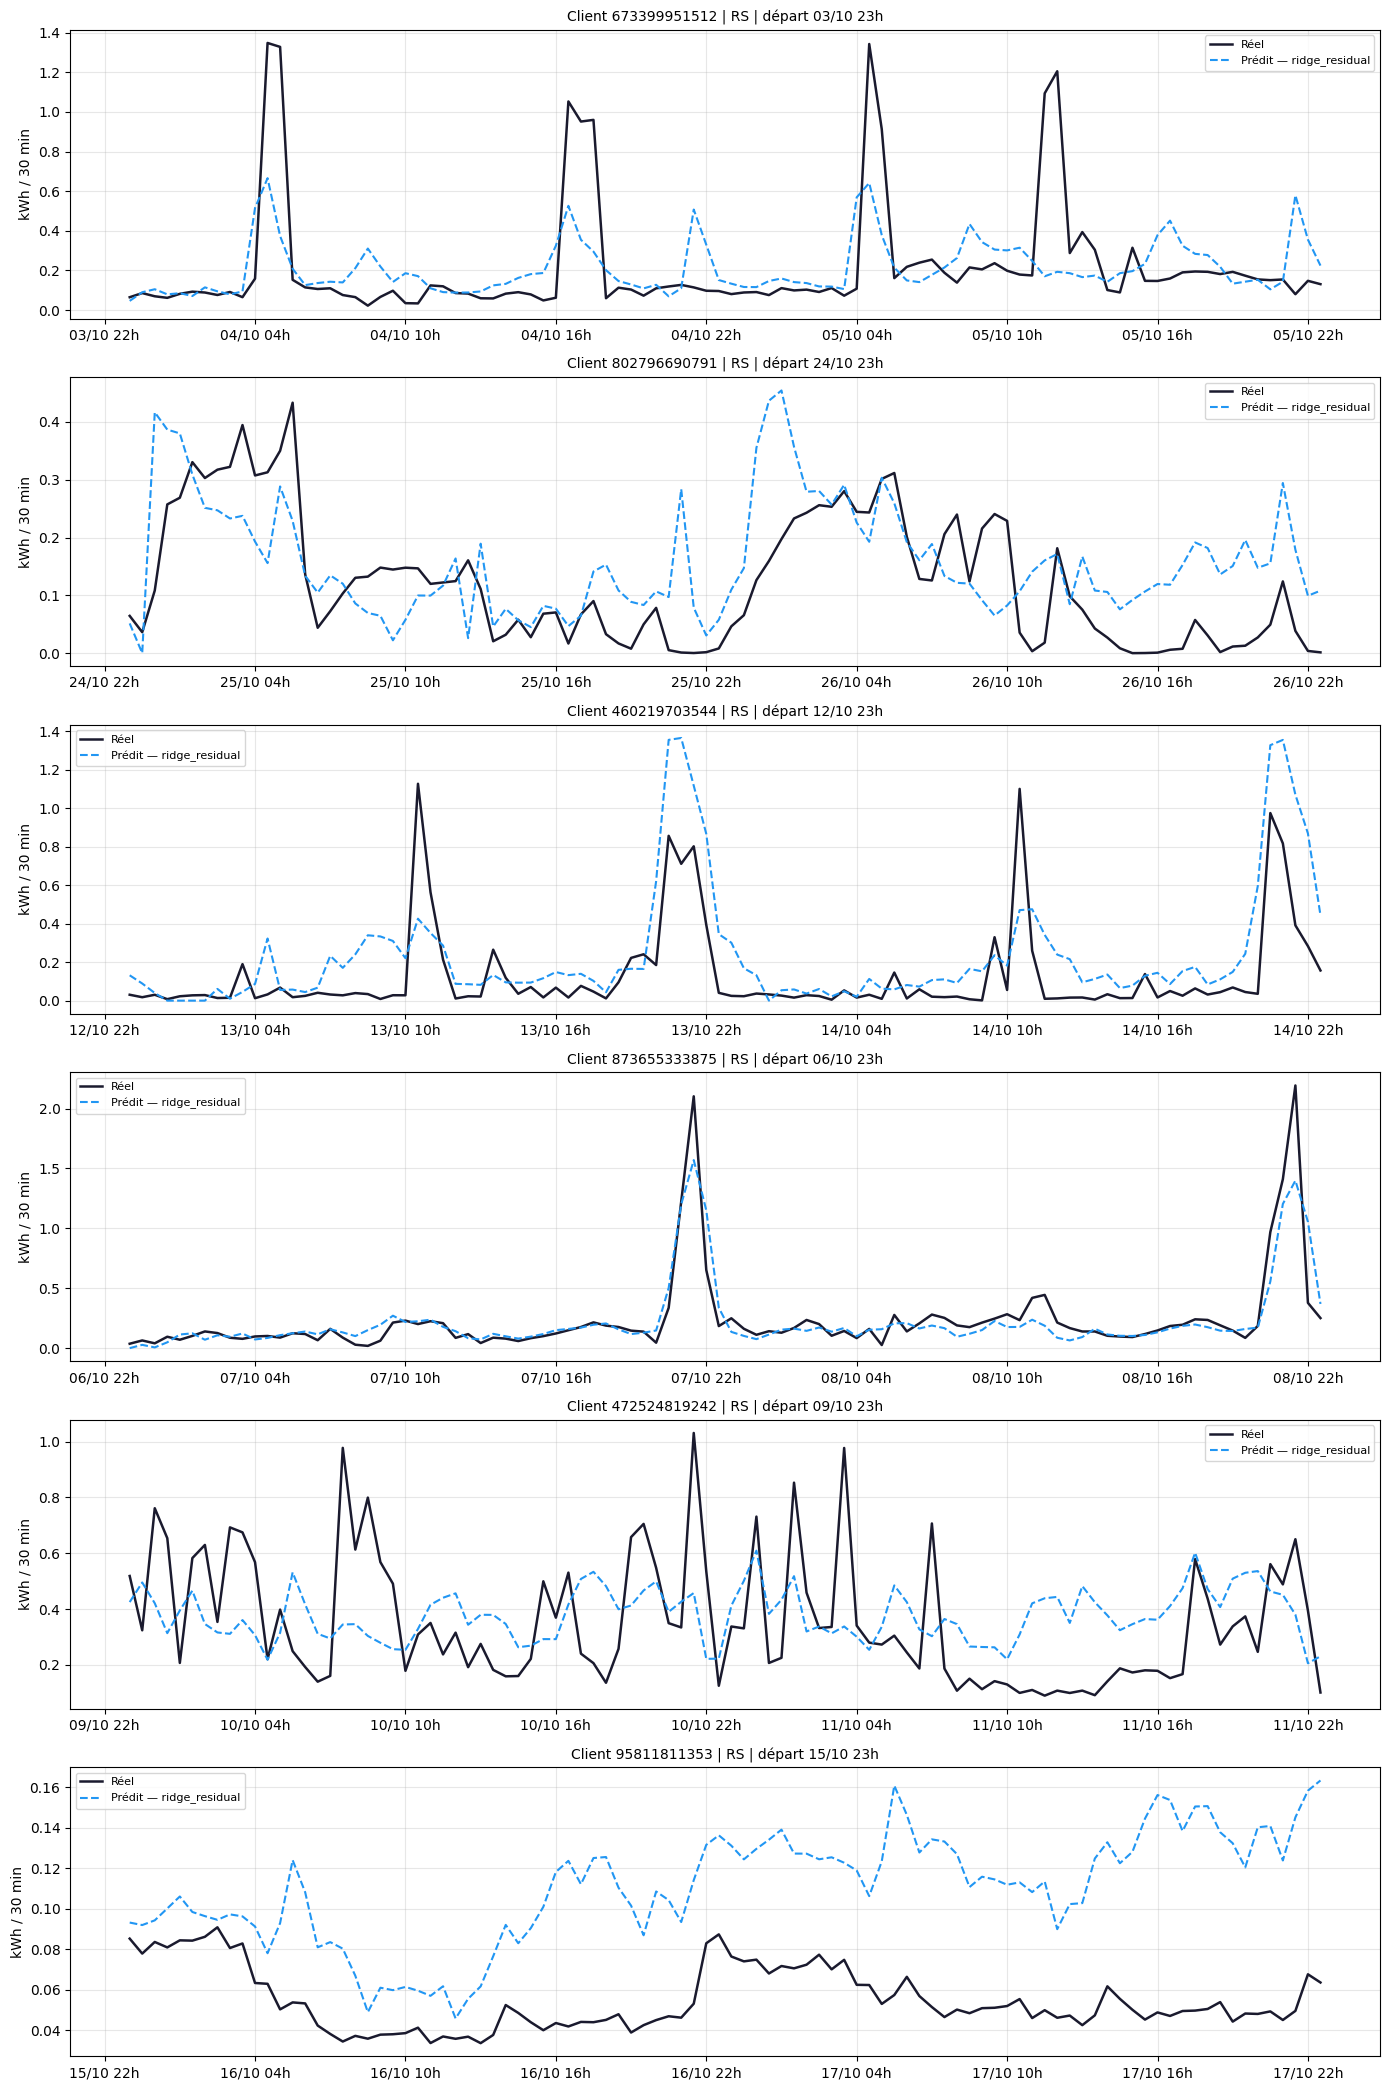

Figure sauvegardée : /outputs/figures/prediction/fig_pred_01_exemples.png


In [ ]:
# igure 1 : Exemples de prédictions (meilleur modèle ALL) 

# Ensure best_by_val is defined, in case of kernel restart or out-of-order execution
if 'best_by_val' not in globals() and 'validation_results' in globals() and 'SELECTION_METRIC' in globals():
    best_by_val = {}
    for seg in ["RS", "RP", "ALL"]:
        df_seg = validation_results[validation_results["segment"] == seg].sort_values(SELECTION_METRIC)
        if len(df_seg):
            row = df_seg.iloc[0]
            best_by_val[seg] = row["modele"]
    print("Warning: best_by_val was not found, re-calculated from validation_results.")
elif 'best_by_val' not in globals():
    # If validation_results or SELECTION_METRIC are also missing, a deeper issue exists.
    # Fallback to a default if the above re-calculation is not possible.
    best_by_val = {"ALL": "baseline_weekly"}
    print("Warning: best_by_val, validation_results or SELECTION_METRIC were not found. Defaulting 'ALL' to 'baseline_weekly'.")


model_to_plot   = best_by_val.get("ALL", "baseline_weekly")
Y_pred_plot     = get_prediction_array(model_to_plot)

rng         = np.random.default_rng(RANDOM_STATE)
plot_indices = rng.choice(idx_test, size=min(6, len(idx_test)), replace=False)

fig, axes = plt.subplots(len(plot_indices), 1, figsize=(14, 3.5 * len(plot_indices)))
if len(plot_indices) == 1:
    axes = [axes]

for ax, idx in zip(axes, plot_indices):
    start_time = forecast_starts.iloc[idx]
    dates      = pd.date_range(start=start_time, periods=HORIZON, freq="30min")
    seg        = windows.iloc[idx]["segment"]
    pdl        = windows.iloc[idx]["pdl_id"]

    ax.plot(dates, Y[idx],           color=PALETTE["Réel"],            lw=1.8, label="Réel")
    ax.plot(dates, Y_pred_plot[idx], color=PALETTE.get(model_to_plot, "#2196F3"),
            lw=1.5, ls="--", label=f"Prédit — {model_to_plot}")
    ax.set_title(f"Client {pdl} | {seg} | départ {start_time.strftime('%d/%m %Hh')}",
                 fontsize=10)
    ax.set_ylabel("kWh / 30 min")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %Hh"))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(FIG_DIR / "fig_pred_01_exemples.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardée : {FIG_DIR / 'fig_pred_01_exemples.png'}")

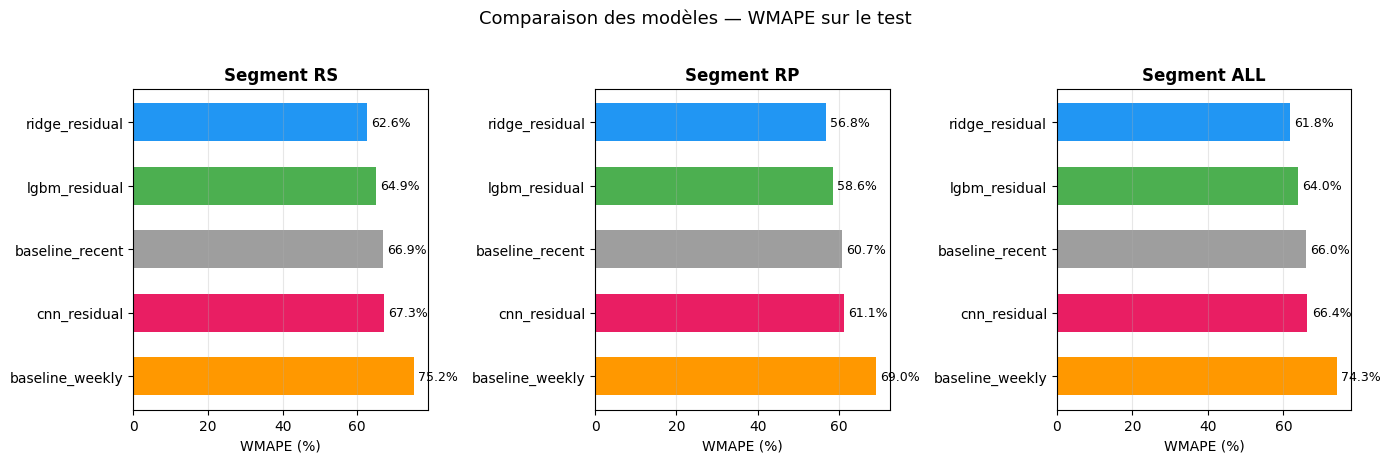

Figure sauvegardée : /outputs/figures/prediction/fig_pred_02_wmape_comparaison.png


In [ ]:
# igure 2 : Comparaison WMAPE sur le test (RS / RP / ALL) 

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=False)

for ax, seg in zip(axes, ["RS", "RP", "ALL"]):
    df_seg = test_results[test_results["segment"] == seg].sort_values("WMAPE")
    colors = [PALETTE.get(m, "#607D8B") for m in df_seg["modele"]]
    bars   = ax.barh(df_seg["modele"], df_seg["WMAPE"], color=colors, height=0.6)
    ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=9)
    ax.set_title(f"Segment {seg}", fontweight="bold")
    ax.set_xlabel("WMAPE (%)")
    ax.grid(axis="x", alpha=0.3)
    ax.invert_yaxis()

fig.suptitle("Comparaison des modèles — WMAPE sur le test", fontsize=13, y=1.02)
plt.tight_layout()
fig.savefig(FIG_DIR / "fig_pred_02_wmape_comparaison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardée : {FIG_DIR / 'fig_pred_02_wmape_comparaison.png'}")

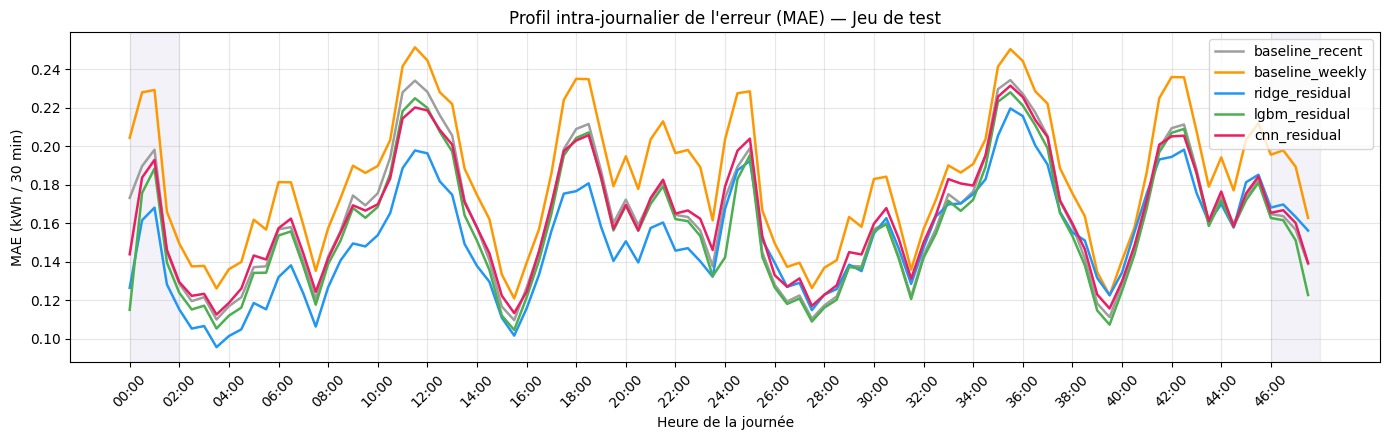

Figure sauvegardée : /outputs/figures/prediction/fig_pred_03_mae_intraday.png


In [ ]:
# gure 3 : MAE par demi-heure (profil intra-journalier de l'erreur) 

hh_labels = [f"{h//2:02d}:{(h%2)*30:02d}" for h in range(HORIZON)]
xticks    = list(range(0, HORIZON, 4))

models_to_compare = [
    ("baseline_recent",  B_recent[idx_test]),
    ("baseline_weekly",  B_weekly[idx_test]),
    ("ridge_residual",   pred_ridge_test),
]
if pred_lgbm_test is not None:
    models_to_compare.append(("lgbm_residual", pred_lgbm_test))
if pred_cnn_test is not None:
    models_to_compare.append(("cnn_residual",  pred_cnn_test))

fig, ax = plt.subplots(figsize=(14, 4.5))
for name, preds in models_to_compare:
    mae_hh = np.abs(Y[idx_test] - preds).mean(axis=0)
    ax.plot(range(HORIZON), mae_hh, label=name, color=PALETTE.get(name, None), lw=1.8)

ax.set_xticks(xticks)
ax.set_xticklabels([hh_labels[i] for i in xticks], rotation=45)
ax.set_xlabel("Heure de la journée")
ax.set_ylabel("MAE (kWh / 30 min)")
ax.set_title("Profil intra-journalier de l'erreur (MAE) — Jeu de test")
ax.legend()
ax.grid(alpha=0.3)

# Marquage des périodes nocturnes
ax.axvspan(0, 4, alpha=0.05, color="navy", label="_nuit")
ax.axvspan(HORIZON-4, HORIZON, alpha=0.05, color="navy")

plt.tight_layout()
fig.savefig(FIG_DIR / "fig_pred_03_mae_intraday.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardée : {FIG_DIR / 'fig_pred_03_mae_intraday.png'}")

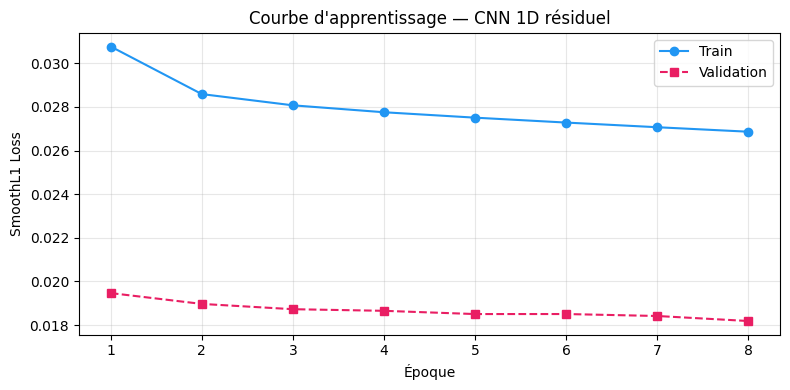

Figure sauvegardée : /outputs/figures/prediction/fig_pred_04_cnn_loss.png


In [ ]:
#  Figure 4 : Courbe de loss CNN (si disponible) 

if cnn_history:
    hist_df = pd.DataFrame(cnn_history)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(hist_df["epoch"], hist_df["train_loss"], "o-", label="Train",      color="#2196F3")
    ax.plot(hist_df["epoch"], hist_df["val_loss"],   "s--", label="Validation", color="#E91E63")
    ax.set_xlabel("Époque")
    ax.set_ylabel("SmoothL1 Loss")
    ax.set_title("Courbe d'apprentissage — CNN 1D résiduel")
    ax.legend()
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    plt.tight_layout()
    fig.savefig(FIG_DIR / "fig_pred_04_cnn_loss.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Figure sauvegardée : {FIG_DIR / 'fig_pred_04_cnn_loss.png'}")
else:
    print("Pas d'historique CNN à tracer.")

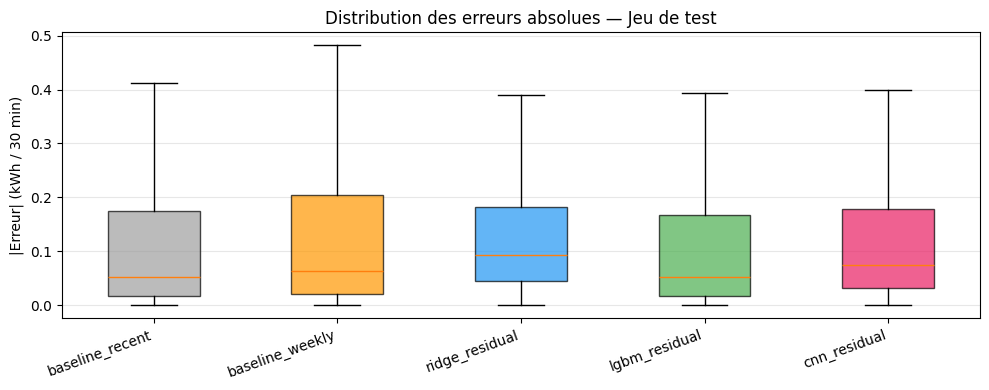

Figure sauvegardée : /outputs/figures/prediction/fig_pred_05_erreurs_boxplot.png


In [ ]:
# gure 5 : Distribution des erreurs (boxplot par modèle) 

error_data, labels_box = [], []
for name, preds in models_to_compare:
    errors = np.abs(Y[idx_test] - preds).flatten()
    error_data.append(errors)
    labels_box.append(name)

fig, ax = plt.subplots(figsize=(10, 4))
bp = ax.boxplot(error_data, patch_artist=True, notch=False,
                showfliers=False, vert=True, widths=0.5)
for patch, name in zip(bp["boxes"], labels_box):
    patch.set_facecolor(PALETTE.get(name, "#607D8B"))
    patch.set_alpha(0.7)

ax.set_xticks(range(1, len(labels_box) + 1))
ax.set_xticklabels(labels_box, rotation=20, ha="right")
ax.set_ylabel("|Erreur| (kWh / 30 min)")
ax.set_title("Distribution des erreurs absolues — Jeu de test")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig(FIG_DIR / "fig_pred_05_erreurs_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardée : {FIG_DIR / 'fig_pred_05_erreurs_boxplot.png'}")

## 11. Fonction de prédiction pour un client donné

Cette fonction prend un `pdl_id`, récupère ses **14 derniers jours** observés et renvoie la prédiction des **2 jours suivants** avec le modèle choisi.

In [ ]:
def predict_next_2_days_for_client(pdl_id, model_name=None):
    """
    Prédit les 2 prochains jours (96 demi-heures) pour un client donné.

    Parameters
    ----------
    pdl_id     : identifiant du client
    model_name : 'baseline_recent', 'baseline_weekly', 'ridge_residual',
                 'lgbm_residual', 'cnn_residual' — None → meilleur ALL

    Returns
    -------
    DataFrame avec colonnes : horodate, prediction_kwh, pdl_id, segment, modele
    """
    if model_name is None:
        model_name = best_by_val.get("ALL", "baseline_weekly")

    g = raw[raw["pdl_id"] == pdl_id].sort_values("horodate")
    if len(g) < INPUT_LEN:
        raise ValueError(f"Historique insuffisant pour le client {pdl_id} "
                         f"({len(g)} points, {INPUT_LEN} requis).")

    segment     = g["segment"].iloc[-1]
    values      = g["kwh"].to_numpy(dtype=np.float32)
    times       = g["horodate"].to_numpy()

    past_seq       = values[-INPUT_LEN:]
    anchor_time    = pd.Timestamp(times[-1])
    forecast_start = anchor_time + pd.Timedelta(minutes=30)
    future_dates   = pd.date_range(start=forecast_start, periods=HORIZON, freq="30min")

    extra    = build_extra_features(past_seq, anchor_time, segment).reshape(1, -1)
    x_seq_1  = past_seq.reshape(1, -1)
    x_tab_1  = np.hstack([x_seq_1, extra]).astype(np.float32)

    b_recent_1 = past_seq[-HORIZON:].reshape(1, -1)
    b_weekly_1 = past_seq[INPUT_LEN-336:INPUT_LEN-336+HORIZON].reshape(1, -1)
    b_base_1   = b_recent_1 if BASELINE_MODEL == "baseline_recent" else b_weekly_1

    if model_name == "baseline_recent":
        pred = b_recent_1[0]
    elif model_name == "baseline_weekly":
        pred = b_weekly_1[0]
    elif model_name == "ridge_residual":
        pred = np.clip(b_base_1 + ridge_model.predict(x_tab_1).astype(np.float32), 0, None)[0]
    elif model_name == "lgbm_residual" and lgbm_model is not None:
        pred = np.clip(b_base_1 + lgbm_model.predict(extra).astype(np.float32), 0, None)[0]
    elif model_name == "cnn_residual" and cnn_model is not None:
        x_seq_sc    = (x_seq_1   / seq_scale).astype(np.float32)
        x_extra_sc  = ((extra - extra_mean) / extra_std).astype(np.float32)
        cnn_model.eval()
        with torch.no_grad():
            res = cnn_model(
                torch.from_numpy(x_seq_sc).to(DEVICE),
                torch.from_numpy(x_extra_sc).to(DEVICE)
            ).cpu().numpy() * seq_scale
        pred = np.clip(b_base_1 + res, 0, None)[0]
    else:
        raise ValueError(f"Modèle inconnu ou non disponible : {model_name}")

    return pd.DataFrame({
        "horodate"       : future_dates,
        "prediction_kwh" : pred,
        "pdl_id"         : pdl_id,
        "segment"        : segment,
        "modele"         : model_name,
    })


# emple d'utilisation 
example_pdl = raw["pdl_id"].iloc[0]
forecast_ex = predict_next_2_days_for_client(example_pdl)
print(f"Prédiction pour le client {example_pdl} :")
display(forecast_ex.head(8))

Prédiction pour le client 1704875583 :


,horodate,prediction_kwh,pdl_id,segment,modele
0,2024-10-29 23:00:00+00:00,0.242811,1704875583,RS,ridge_residual
1,2024-10-29 23:30:00+00:00,0.210879,1704875583,RS,ridge_residual
2,2024-10-30 00:00:00+00:00,0.179672,1704875583,RS,ridge_residual
3,2024-10-30 00:30:00+00:00,0.218602,1704875583,RS,ridge_residual
4,2024-10-30 01:00:00+00:00,0.228498,1704875583,RS,ridge_residual
5,2024-10-30 01:30:00+00:00,0.202135,1704875583,RS,ridge_residual
6,2024-10-30 02:00:00+00:00,0.198230,1704875583,RS,ridge_residual
7,2024-10-30 02:30:00+00:00,0.221309,1704875583,RS,ridge_residual


In [38]:
output_csv_path = FIG_DIR / "client_forecast_example.csv"
forecast_ex.to_csv(output_csv_path, index=False)
print(f"Prédictions sauvegardées dans : {output_csv_path}")

Prédictions sauvegardées dans : /outputs/figures/prediction/client_forecast_example.csv


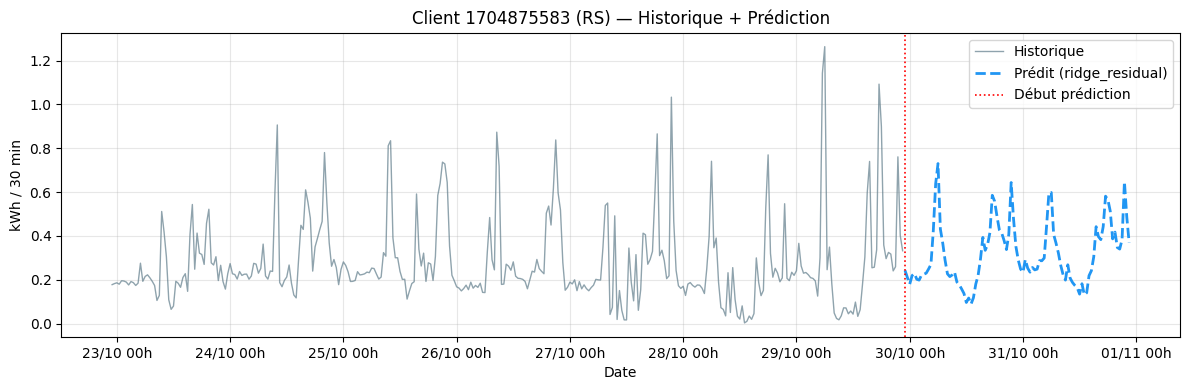

Figure sauvegardée : /outputs/figures/prediction/fig_pred_06_client_preview.png


In [ ]:
# re 6 : Visualisation de la prédiction sur un client unique 

fig, ax = plt.subplots(figsize=(12, 4))

# Historique récent (7 derniers jours)
g_ex    = raw[raw["pdl_id"] == example_pdl].sort_values("horodate").tail(INPUT_LEN // 2)
ax.plot(g_ex["horodate"], g_ex["kwh"], color="#607D8B", lw=1, alpha=0.7, label="Historique")

# Prédiction
ax.plot(forecast_ex["horodate"], forecast_ex["prediction_kwh"],
        color=PALETTE.get(forecast_ex["modele"].iloc[0], "#2196F3"),
        lw=2, ls="--", label=f"Prédit ({forecast_ex['modele'].iloc[0]})")

# Limite passé/futur
ax.axvline(forecast_ex["horodate"].iloc[0], color="red", lw=1.2, ls=":", label="Début prédiction")

ax.set_xlabel("Date")
ax.set_ylabel("kWh / 30 min")
ax.set_title(f"Client {example_pdl} ({forecast_ex['segment'].iloc[0]}) — Historique + Prédiction")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %Hh"))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(FIG_DIR / "fig_pred_06_client_preview.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardée : {FIG_DIR / 'fig_pred_06_client_preview.png'}")

In [ ]:
# capitulatif des figures sauvegardées 
print("\n── Figures sauvegardées dans", FIG_DIR, "──")
for f in sorted(FIG_DIR.glob("fig_pred_*.png")):
    print(f"  {f.name}")


── Figures sauvegardées dans /outputs/figures/prediction ──
  fig_pred_01_exemples.png
  fig_pred_02_wmape_comparaison.png
  fig_pred_03_mae_intraday.png
  fig_pred_04_cnn_loss.png
  fig_pred_05_erreurs_boxplot.png
  fig_pred_06_client_preview.png


## 12. Sauvegarde des résultats complets et des fenêtres (échantillon)

In [39]:
output_test_results_path = FIG_DIR / "prediction_results.csv"
test_results.to_csv(output_test_results_path, index=False)
print(f"Résultats de test sauvegardés dans : {output_test_results_path}")

Résultats de test sauvegardés dans : /outputs/figures/prediction/prediction_results.csv


In [40]:
# Sample the windows DataFrame to avoid excessively large files
sampled_windows = windows.sample(n=min(1000, len(windows)), random_state=RANDOM_STATE).reset_index(drop=True)

output_windows_sample_path = FIG_DIR / "prediction_windows_sample.csv"
# Convert 'x_seq', 'x_extra', 'y', 'b_recent', 'b_weekly' columns (numpy arrays) to string representation
for col in ['x_seq', 'x_extra', 'y', 'b_recent', 'b_weekly']:
    sampled_windows[col] = sampled_windows[col].apply(lambda x: str(x.tolist()))
sampled_windows.to_csv(output_windows_sample_path, index=False)
print(f"Échantillon des fenêtres sauvegardé dans : {output_windows_sample_path}")

Échantillon des fenêtres sauvegardé dans : /outputs/figures/prediction/prediction_windows_sample.csv


In [41]:
print("\n── Fichiers de données sauvegardés dans", FIG_DIR, "──")
for f in sorted(FIG_DIR.glob("*.csv")):
    print(f"  {f.name}")


── Fichiers de données sauvegardés dans /outputs/figures/prediction ──
  client_forecast_example.csv
  prediction_results.csv
  prediction_windows_sample.csv
